In [1]:
# 1 => Rice_Cammeo_Osmancik.xlsx
# 2 => Synthetic-Infant-Health-Data.csv
# 3 => wine-new.csv

In [ ]:
# steps =>

# 1. import data
# 2. data cleaning -> inconsistencies, missing values
# 3. Exploratory data analysis
# 4. Outlier detection and removal
# 5. Data balancing / Resampling
# 6. feature selection/ dimensionality reduction
# 7. cross validation
# 8. Feature scaling
# 9. Algorithms and hyperpara tuning
# 10. model building
# 11. predictions
# 12. deployment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# 1 => Rice_Cammeo_Osmancik.xlsx
# 2 => Synthetic-Infant-Health-Data.csv
# 3 => wine-new.csv

In [3]:
df = pd.read_csv('grapes_new.csv')
df.head()

,COLOR_INTENSITY,SHAPE,RIPENESS_PER,ALCOHOL_PER,MALIC_ACID_PER,ASH,ALCALINITY_OF_ASH,MAGNESIUM_MEASURE,TOTAL_PHENOLS,FLAVANOIDS,...,HUE,PROLINE,TEMPERATURE,AVG_HUMIDITY,FERT_NITRO_PER,WATER_O2_PER,WATER_PH,FER_P2O5_PER,SOIL_TYPE,CLASS
0,120.53,elliptical,16.73,14.23,1.71,2.43,15.6,127,2.80,3.06,...,1.04,1065,23.34,54.99,31.21,97.67,7.71,52.02,archean,High
1,112.57,elliptical,20.30,13.20,1.78,2.14,11.2,100,2.65,2.76,...,1.05,1050,23.40,51.91,31.28,99.05,7.66,48.18,archean,High
2,120.78,elliptical,20.81,13.16,2.36,2.67,18.6,101,2.80,3.24,...,1.03,1185,22.29,50.69,31.92,97.95,7.66,28.15,archean,High
3,134.17,elliptical,19.47,14.37,1.95,2.50,16.8,113,3.85,3.49,...,0.86,1480,21.28,47.72,31.79,95.46,7.21,55.95,alluvial,High
4,112.19,round,17.57,13.24,2.59,2.87,21.0,118,2.80,2.69,...,1.04,735,23.76,45.09,31.86,94.45,7.80,55.99,archean,High


In [6]:
df.shape

(194, 21)

## Data Cleaning

In [8]:
df.columns

Index(['COLOR_INTENSITY', 'SHAPE', 'RIPENESS_PER', 'ALCOHOL_PER',
       'MALIC_ACID_PER', 'ASH', 'ALCALINITY_OF_ASH', 'MAGNESIUM_MEASURE',
       'TOTAL_PHENOLS', 'FLAVANOIDS', 'PROANTHOCYANINS', 'HUE', 'PROLINE',
       'TEMPERATURE', 'AVG_HUMIDITY', 'FERT_NITRO_PER', 'WATER_O2_PER',
       'WATER_PH', 'FER_P2O5_PER', 'SOIL_TYPE', 'CLASS'],
      dtype='object')

In [4]:
df.columns = df.columns.str.strip()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   COLOR_INTENSITY    194 non-null    float64
 1   SHAPE              194 non-null    object 
 2   RIPENESS_PER       192 non-null    float64
 3   ALCOHOL_PER        191 non-null    float64
 4   MALIC_ACID_PER     194 non-null    float64
 5   ASH                194 non-null    float64
 6   ALCALINITY_OF_ASH  188 non-null    float64
 7   MAGNESIUM_MEASURE  194 non-null    int64  
 8   TOTAL_PHENOLS      194 non-null    float64
 9   FLAVANOIDS         194 non-null    float64
 10  PROANTHOCYANINS    194 non-null    float64
 11  HUE                192 non-null    float64
 12  PROLINE            194 non-null    int64  
 13  TEMPERATURE        194 non-null    float64
 14  AVG_HUMIDITY       194 non-null    float64
 15  FERT_NITRO_PER     194 non-null    float64
 16  WATER_O2_PER       190 non

In [6]:
df.isna().sum()

COLOR_INTENSITY      0
SHAPE                0
RIPENESS_PER         2
ALCOHOL_PER          3
MALIC_ACID_PER       0
ASH                  0
ALCALINITY_OF_ASH    6
MAGNESIUM_MEASURE    0
TOTAL_PHENOLS        0
FLAVANOIDS           0
PROANTHOCYANINS      0
HUE                  2
PROLINE              0
TEMPERATURE          0
AVG_HUMIDITY         0
FERT_NITRO_PER       0
WATER_O2_PER         4
WATER_PH             0
FER_P2O5_PER         0
SOIL_TYPE            0
CLASS                0
dtype: int64

In [7]:
df.ffill(inplace=True)

In [8]:
df.isnull().sum()

COLOR_INTENSITY      0
SHAPE                0
RIPENESS_PER         0
ALCOHOL_PER          0
MALIC_ACID_PER       0
ASH                  0
ALCALINITY_OF_ASH    0
MAGNESIUM_MEASURE    0
TOTAL_PHENOLS        0
FLAVANOIDS           0
PROANTHOCYANINS      0
HUE                  0
PROLINE              0
TEMPERATURE          0
AVG_HUMIDITY         0
FERT_NITRO_PER       0
WATER_O2_PER         0
WATER_PH             0
FER_P2O5_PER         0
SOIL_TYPE            0
CLASS                0
dtype: int64

In [9]:
# separate input and output

In [10]:
x = df.drop('CLASS', axis = 1)
y = df['CLASS']

## EDA

In [11]:
x.describe()

,COLOR_INTENSITY,RIPENESS_PER,ALCOHOL_PER,MALIC_ACID_PER,ASH,ALCALINITY_OF_ASH,MAGNESIUM_MEASURE,TOTAL_PHENOLS,FLAVANOIDS,PROANTHOCYANINS,HUE,PROLINE,TEMPERATURE,AVG_HUMIDITY,FERT_NITRO_PER,WATER_O2_PER,WATER_PH,FER_P2O5_PER
count,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000
mean,116.882113,21.508557,13.038454,2.335103,2.365361,19.570619,99.680412,2.296649,2.016856,1.577216,0.956866,754.164948,26.418247,50.976082,30.562216,90.349381,7.680979,42.195155
std,14.333204,2.374497,0.815124,1.118041,0.268158,3.441775,14.252749,0.634317,1.001351,0.565445,0.227370,316.093797,3.042364,3.367880,1.126867,5.438735,0.509935,10.398205
min,93.000000,16.170000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.410000,0.480000,278.000000,21.020000,44.230000,27.670000,80.360000,6.510000,20.000000
25%,105.470000,20.372500,12.370000,1.610000,2.210000,17.200000,88.000000,1.725000,1.092500,1.225000,0.790000,504.000000,24.222500,48.360000,29.932500,85.862500,7.252500,33.742500
50%,114.910000,21.800000,13.050000,1.865000,2.360000,19.500000,97.500000,2.355000,2.135000,1.545000,0.980000,675.000000,26.195000,51.145000,30.710000,90.550000,7.670000,44.820000
75%,124.060000,23.317500,13.705000,3.082500,2.547500,21.500000,107.000000,2.800000,2.875000,1.950000,1.117500,988.750000,28.737500,53.722500,31.382500,94.897500,8.127500,50.542500
max,167.000000,25.200000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,3.580000,1.710000,1680.000000,32.340000,57.950000,34.160000,99.770000,8.500000,60.870000


In [12]:
x.shape

(194, 20)

In [19]:
one = df.iloc[:, :4]
one['CLASS'] = y
two = df.iloc[:, 4:8]
two['CLASS'] = y
three = df.iloc[:, 8:12]
three['CLASS'] = y
four = df.iloc[:, 12:16]
four['CLASS'] = y
five = df.iloc[:, 16:20]
five['CLASS'] = y

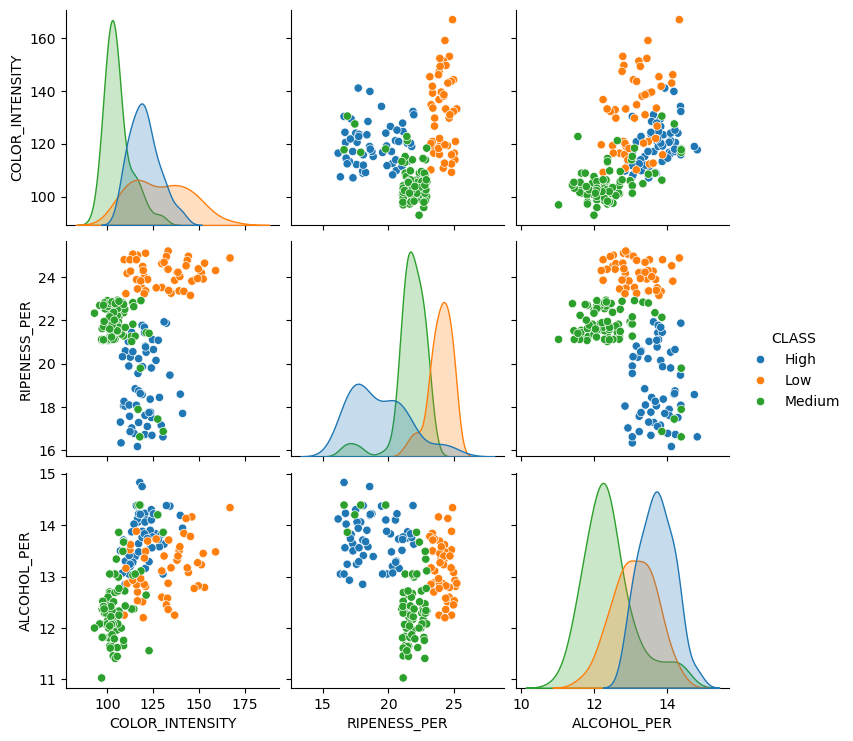

In [20]:
sns.pairplot(one, hue = 'CLASS');

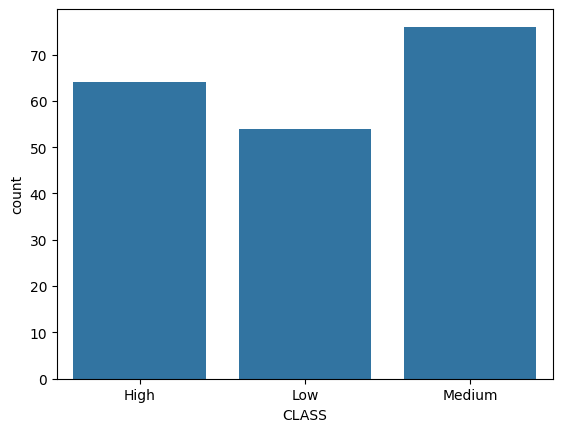

In [22]:
# check for data balance

sns.countplot(x = y);

## Outlier Detection and Removal

In [23]:
x.dtypes

COLOR_INTENSITY      float64
RIPENESS_PER         float64
ALCOHOL_PER          float64
MALIC_ACID_PER       float64
ASH                  float64
ALCALINITY_OF_ASH    float64
MAGNESIUM_MEASURE      int64
TOTAL_PHENOLS        float64
FLAVANOIDS           float64
PROANTHOCYANINS      float64
HUE                  float64
PROLINE                int64
TEMPERATURE          float64
AVG_HUMIDITY         float64
FERT_NITRO_PER       float64
WATER_O2_PER         float64
WATER_PH             float64
FER_P2O5_PER         float64
SHAPE_round             bool
SOIL_TYPE_archean       bool
dtype: object

In [24]:
# one hot enode

x = pd.get_dummies(x, drop_first= True)

In [25]:
col_order_ohe = x.columns.tolist()

In [26]:
col_order_ohe

['COLOR_INTENSITY',
 'RIPENESS_PER',
 'ALCOHOL_PER',
 'MALIC_ACID_PER',
 'ASH',
 'ALCALINITY_OF_ASH',
 'MAGNESIUM_MEASURE',
 'TOTAL_PHENOLS',
 'FLAVANOIDS',
 'PROANTHOCYANINS',
 'HUE',
 'PROLINE',
 'TEMPERATURE',
 'AVG_HUMIDITY',
 'FERT_NITRO_PER',
 'WATER_O2_PER',
 'WATER_PH',
 'FER_P2O5_PER',
 'SHAPE_round',
 'SOIL_TYPE_archean']

In [27]:
# isolation forest for outlier removal

In [28]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination= 0.05, random_state= 0)

In [29]:
clean = iso.fit_predict(x)

In [30]:
clean

array([ 1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1])

In [31]:
x = x[clean == 1]
y = y[clean == 1]

In [32]:
x.shape

(184, 20)

## Sampling (over sampling)

In [33]:
y.shape

(184,)

In [34]:
y.value_counts()

CLASS
Medium    72
High      63
Low       49
Name: count, dtype: int64

In [35]:
# imbalanced-learn

In [36]:
# !pip install imblearn;

In [37]:
from imblearn.over_sampling import SMOTE

In [38]:
smote = SMOTE(k_neighbors= 5)

In [39]:
x_res, y_res = smote.fit_resample(x, y)

In [40]:
y_res.value_counts()

CLASS
High      72
Low       72
Medium    72
Name: count, dtype: int64

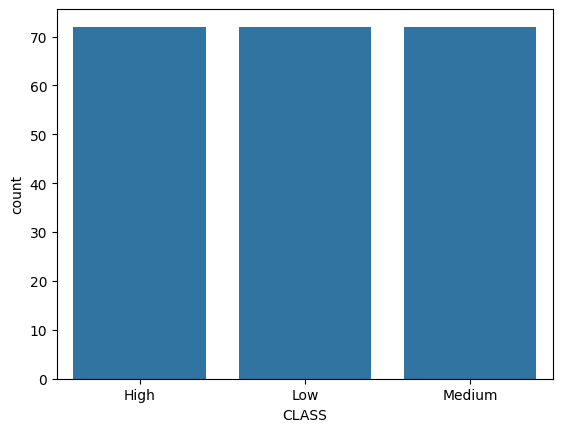

In [41]:
sns.countplot(x = y_res);

## Feature Selection

In [42]:
from sklearn.feature_selection import SelectKBest, chi2

In [43]:
skf = SelectKBest(k = 5, score_func = chi2)

In [44]:
x_new = skf.fit_transform(x_res, y_res)

In [45]:
x_new.shape

(216, 5)

In [46]:
skf.get_support()

array([ True, False, False, False, False, False, False, False,  True,
       False, False,  True,  True, False, False, False, False,  True,
       False, False])

In [48]:
skf.get_feature_names_out()

array(['COLOR_INTENSITY', 'FLAVANOIDS', 'PROLINE', 'TEMPERATURE',
       'FER_P2O5_PER'], dtype=object)

In [49]:
x = x_res.loc[:,skf.get_support()]

In [50]:
x;

In [51]:
x.shape, y_res.shape

((216, 5), (216,))

In [52]:
x.describe()

,COLOR_INTENSITY,FLAVANOIDS,PROLINE,TEMPERATURE,FER_P2O5_PER
count,216.000000,216.000000,216.000000,216.000000,216.000000
mean,117.663776,1.915804,755.527778,26.614600,41.621822
std,13.845594,0.986569,309.248074,3.084689,10.027204
min,93.000000,0.470000,278.000000,21.020000,20.000000
25%,106.390000,0.899174,510.000000,24.237500,33.926850
50%,116.490000,2.020000,680.000000,26.340000,43.571315
75%,124.718696,2.765439,986.250000,29.229579,48.970000
max,153.110000,3.930000,1680.000000,32.340000,60.870000


## cross validation

In [54]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y_res,
                                                   random_state= 0,
                                                   test_size= 0.2,
                                                   stratify= y_res)

In [55]:
x_train.shape, y_train.shape

((172, 5), (172,))

# Feature Scaling

In [56]:
from sklearn.preprocessing import MinMaxScaler
sca = MinMaxScaler()

x_train_scaled = sca.fit_transform(x_train)
x_test_scaled = sca.transform(x_test)

In [57]:
x_train_scaled.shape, y_train.shape

((172, 5), (172,))

## Build the model

In [59]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [60]:
params = {'random_state': [0, 42],
         'criterion': ['gini', 'entropy'],
         'max_features': ['sqrt', 'log2'],
         'n_estimators': [20, 30, 100]}

In [61]:
grid = GridSearchCV(estimator= RandomForestClassifier(),
                   param_grid= params,
                   scoring = 'accuracy',
                   cv = 5)

In [62]:
grid.fit(x_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_features': ['sqrt', 'log2'], 'n_estimators': [20, 30, ...], 'random_state': [0, 42]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [63]:
y_pred = grid.predict(x_test_scaled)

In [64]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

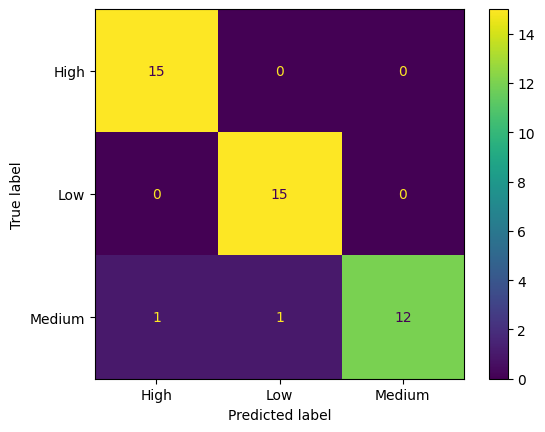

In [65]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

In [66]:
42/44

0.9545454545454546

In [67]:
accuracy_score(y_test, y_pred)

0.9545454545454546

In [68]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.94      1.00      0.97        15
         Low       0.94      1.00      0.97        15
      Medium       1.00      0.86      0.92        14

    accuracy                           0.95        44
   macro avg       0.96      0.95      0.95        44
weighted avg       0.96      0.95      0.95        44



In [69]:
grid.best_params_

{'criterion': 'gini',
 'max_features': 'sqrt',
 'n_estimators': 100,
 'random_state': 0}

In [70]:
grid.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Serialize

In [71]:
import joblib

In [72]:
# save the model

joblib.dump(grid, 'rf_classifier.pkl')

['rf_classifier.pkl']

In [73]:
joblib.dump(sca, 'rf_scaler.pkl')

['rf_scaler.pkl']

In [168]:
x.columns

Index(['COLOR_INTENSITY', 'FLAVANOIDS', 'PROLINE', 'TEMPERATURE',
       'FER_P2O5_PER'],
      dtype='object')

In [170]:
x

,COLOR_INTENSITY,FLAVANOIDS,PROLINE,TEMPERATURE,FER_P2O5_PER
0,120.530000,3.060000,1065,23.340000,52.020000
1,112.570000,2.760000,1050,23.400000,48.180000
2,120.780000,3.240000,1185,22.290000,28.150000
3,112.190000,2.690000,735,23.760000,55.990000
4,127.540000,3.390000,1450,22.230000,39.860000
...,...,...,...,...,...
211,112.648155,1.200786,629,29.090610,34.628683
212,110.941201,0.552758,830,29.087972,34.824287
213,143.461402,0.985701,556,32.188069,34.548222
214,146.706029,0.685766,675,31.922577,43.009486
